In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [127]:
df = pd.read_csv('titanic_data.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [128]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

In [129]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S


In [130]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [131]:
y = df['Survived']
x = df.drop('Survived', axis=1)
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,third,male,22.0,1,0,7.2500,NaN,S
1,first,female,38.0,1,0,71.2833,C85,C
2,third,female,26.0,0,0,7.9250,NaN,S
3,first,female,35.0,1,0,53.1000,C123,S
4,third,male,35.0,0,0,8.0500,NaN,S


### 3.5 Train_Test Split Code


In [132]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=42)

In [133]:
y_train

331     no
733     no
382     no
704     no
813     no
      ... 
106    yes
270     no
860     no
435    yes
102     no
Name: Survived, Length: 712, dtype: object

### 3.6 Handling Missing Values

### 3.7 Numerical Missing value Imputation using Pandas

In [134]:
x_train.isnull().sum()

Pclass        0
Sex           0
Age         140
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      2
dtype: int64

In [135]:
#mean impute
age_mean = x_train['Age'].mean()

x_train['age_mean_imputor'] = x_train['Age'].fillna(age_mean)

x_test['age_mean_imputor'] = x_test['Age'].fillna(age_mean)

In [136]:
#median impute
age_median = x_train['Age'].median()

x_train['age_median_imputor'] = x_train['Age'].fillna(age_median)

x_test['age_median_imputor'] = x_test['Age'].fillna(age_median)

x_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,age_mean_imputor,age_median_imputor
331,first,male,45.5,0,0,28.5000,C124,S,45.5,45.5
733,second,male,23.0,0,0,13.0000,NaN,S,23.0,23.0
382,third,male,32.0,0,0,7.9250,NaN,S,32.0,32.0
704,third,male,26.0,1,0,7.8542,NaN,S,26.0,26.0
813,third,female,6.0,4,2,31.2750,NaN,S,6.0,6.0


<Axes: xlabel='age_mean_imputor', ylabel='Density'>

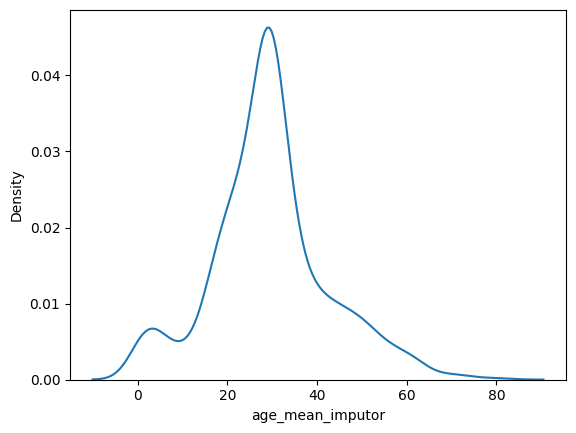

In [137]:
sns.kdeplot(x_train['age_mean_imputor'], label='mean impute')

<Axes: xlabel='age_median_imputor', ylabel='Density'>

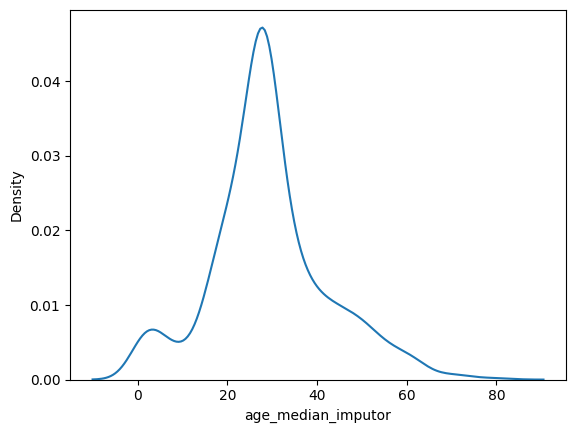

In [138]:
sns.kdeplot(x_train['age_median_imputor'], label='median impute')

### 3.8 Numerical Missing Values Imputation using Simple Imputer

In [139]:
from sklearn.impute import SimpleImputer
import numpy as np

age_imputer = SimpleImputer(missing_values=np.nan, strategy='mean')

age_imputer.fit(x_train[['Age']])

x_train['Age'] = age_imputer.transform(x_train[['Age']]).ravel()

In [140]:
x_train.isnull().sum()

x_train.drop(['age_mean_imputor', 'age_median_imputor'], axis=1, inplace=True, errors='ignore')
x_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,first,male,45.5,0,0,28.5000,C124,S
733,second,male,23.0,0,0,13.0000,NaN,S
382,third,male,32.0,0,0,7.9250,NaN,S
704,third,male,26.0,1,0,7.8542,NaN,S
813,third,female,6.0,4,2,31.2750,NaN,S


In [141]:
x_test['Age'] = age_imputer.transform(x_test[['Age']]).ravel()
x_test.isnull().sum()

Pclass                  0
Sex                     0
Age                     0
SibSp                   0
Parch                   0
Fare                    0
Cabin                 134
Embarked                0
age_mean_imputor        0
age_median_imputor      0
dtype: int64

In [142]:
x_test.drop(['age_mean_imputor', 'age_median_imputor'], axis=1, inplace=True, errors='ignore')
x_test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,third,male,29.498846,1,1,15.2458,NaN,C
439,second,male,31.000000,0,0,10.5000,NaN,S
840,third,male,20.000000,0,0,7.9250,NaN,S
720,second,female,6.000000,0,1,33.0000,NaN,S
39,third,female,14.000000,1,0,11.2417,NaN,C


### 3.9 Categorical Value Imputation with Mode Value

In [143]:
embarked_imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

embarked_imputer.fit(x_train[['Embarked']])

x_train['Embarked'] = embarked_imputer.transform(x_train[['Embarked']]).ravel()
x_test['Embarked'] = embarked_imputer.transform(x_test[['Embarked']]).ravel()

In [144]:
x_train.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      0
dtype: int64

### 3.10 Categorical Value Imputation with Missing string and Indicator


<Axes: xlabel='Cabin', ylabel='count'>

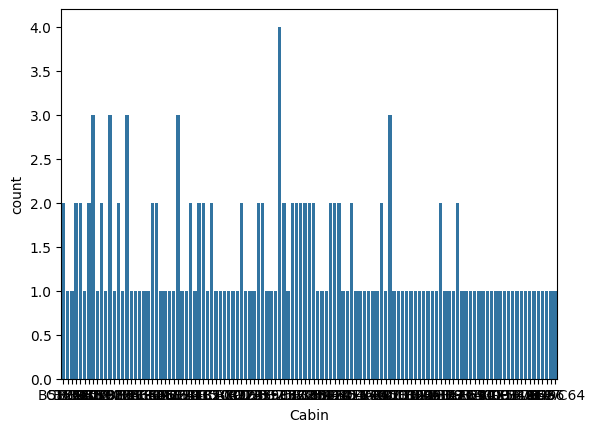

In [146]:
sns.countplot(data = x_train, x = 'Cabin')

In [149]:
cabin_imputer = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='missing', add_indicator=True)

cabin_imputer.fit(x_train[['Cabin']])

x_train[[ 'Cabin','Cabin_missing']] = cabin_imputer.transform(x_train[['Cabin']]).ravel()
x_test[[  'Cabin','Cabin_missing']] = cabin_imputer.transform(x_test[['Cabin']]).ravel()

ValueError: Columns must be same length as key